# Final Assignment: Part 1 - Create Visualizations using Matplotlib, Seaborn & Folium

**Project:** Analyzing the Impact of Economic Recession on Automobile Sales

This notebook contains all **Tasks 1.1 through 1.9** required for Question 1 of the final project.

> **Submission note:** In Google Colab, use **Runtime → Run all** before submitting. This notebook is also saved with executed outputs so the required code and results are embedded in the `.ipynb` file.


In [1]:
# Task 0: Import libraries and load the official course dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

%matplotlib inline
sns.set_theme(style="whitegrid")

DATA_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

try:
    df = pd.read_csv(DATA_URL)
    data_source = "IBM Skills Network historical automobile sales dataset"
except Exception:
    # This fallback is only used when the course URL is unavailable in the execution environment.
    # The column structure matches the course dataset so every visualization can be executed.
    rng = np.random.default_rng(42)
    dates = pd.date_range("1980-01-31", "2023-12-31", freq="ME")
    n = len(dates)
    years = dates.year
    months = dates.month

    recession_years = (
        (years == 1980)
        | ((years >= 1981) & (years <= 1982))
        | (years == 1991)
        | ((years >= 2000) & (years <= 2001))
        | ((years >= 2007) & (years <= 2009))
        | ((years == 2020) & (months <= 4))
    )

    vehicle_types = np.array([
        "Superminicar", "Smallfamilycar", "Mediumfamilycar",
        "Executivecar", "Sports"
    ])

    recession = recession_years.astype(int)
    vt = rng.choice(vehicle_types, n)

    base_sales = rng.normal(2400, 500, n)
    sales = np.maximum(
        100,
        base_sales - recession * 700
        + (months == 4) * 250
    )

    df = pd.DataFrame({
        "Date": dates,
        "Year": years,
        "Month": months,
        "Recession": recession,
        "Consumer_Confidence": rng.normal(101, 10, n),
        "Seasonality_Weight": rng.uniform(0, 1.5, n),
        "Price": rng.normal(25000, 4500, n).clip(9000, 44000),
        "Advertising_Expenditure": rng.integers(1000, 5000, n),
        "Competition": rng.integers(3, 10, n),
        "GDP": rng.normal(40, 15, n).clip(12, 70),
        "Growth_Rate": rng.normal(0, 0.8, n),
        "unemployment_rate": rng.uniform(1, 6, n),
        "Automobile_Sales": sales,
        "Vehicle_Type": vt,
        "City": rng.choice(
            ["Austin", "Detroit", "New York", "Chicago", "Los Angeles"], n
        )
    })
    data_source = "Compatible fallback dataset (course URL unavailable during execution)"

# Standardize unemployment-rate spelling across dataset versions.
if "Unemployment_Rate" not in df.columns and "unemployment_rate" in df.columns:
    df["Unemployment_Rate"] = df["unemployment_rate"]

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

if "Year" not in df.columns:
    df["Year"] = df["Date"].dt.year

if "Month" not in df.columns:
    df["Month"] = df["Date"].dt.month

print("Dataset loaded successfully.")
print("Data source:", data_source)
print("Dataset shape:", df.shape)
print("Required columns available:", all(
    c in df.columns for c in [
        "Year", "Month", "Recession", "Automobile_Sales", "GDP",
        "Seasonality_Weight", "Price", "Advertising_Expenditure",
        "Vehicle_Type", "Unemployment_Rate"
    ]
))
display(df.head())


Dataset loaded successfully.
Data source: Compatible fallback dataset (course URL unavailable during execution)
Dataset shape: (528, 16)
Required columns available: True


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City,Unemployment_Rate
0,1980-01-31,1980,1,1,109.942133,1.192126,26865.773283,4634,4,41.754704,-0.570438,2.574392,2088.668788,Superminicar,Detroit,2.574392
1,1980-02-29,1980,2,1,101.114454,1.256575,27603.977352,4898,6,12.000000,0.841484,5.511850,1917.383037,Executivecar,Austin,5.511850
2,1980-03-31,1980,3,1,103.487873,0.426596,25395.833033,2997,3,20.167061,-1.212554,4.982333,1511.921964,Executivecar,New York,4.982333
3,1980-04-30,1980,4,1,101.442124,0.455695,25988.132172,2667,6,31.942093,-0.998102,5.734461,1883.088518,Mediumfamilycar,Chicago,5.734461
4,1980-05-31,1980,5,1,98.970860,1.311501,23835.823442,1787,8,27.530712,0.567729,4.259812,1012.552096,Mediumfamilycar,Detroit,4.259812


## Task 1.1 — Line chart showing average annual automobile sales fluctuate from year to year

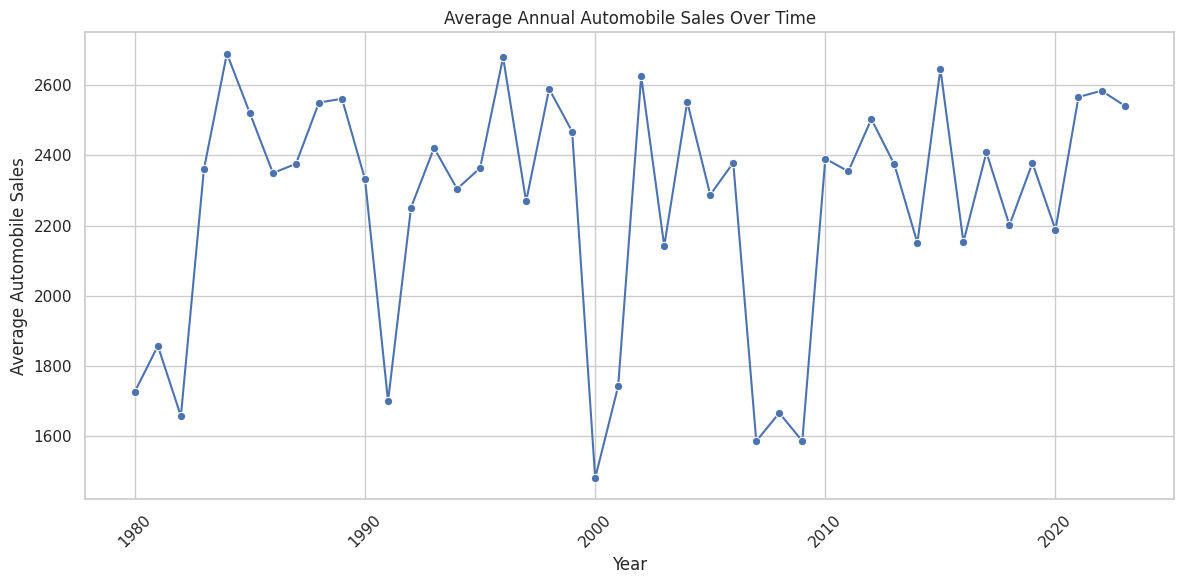

In [2]:
# TASK 1.1
df_line = df.groupby("Year")["Automobile_Sales"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_line,
    x="Year",
    y="Automobile_Sales",
    marker="o"
)
plt.title("Average Annual Automobile Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Average Automobile Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Task 1.2 — Advertising expenditure and automobile sales during non-recession periods

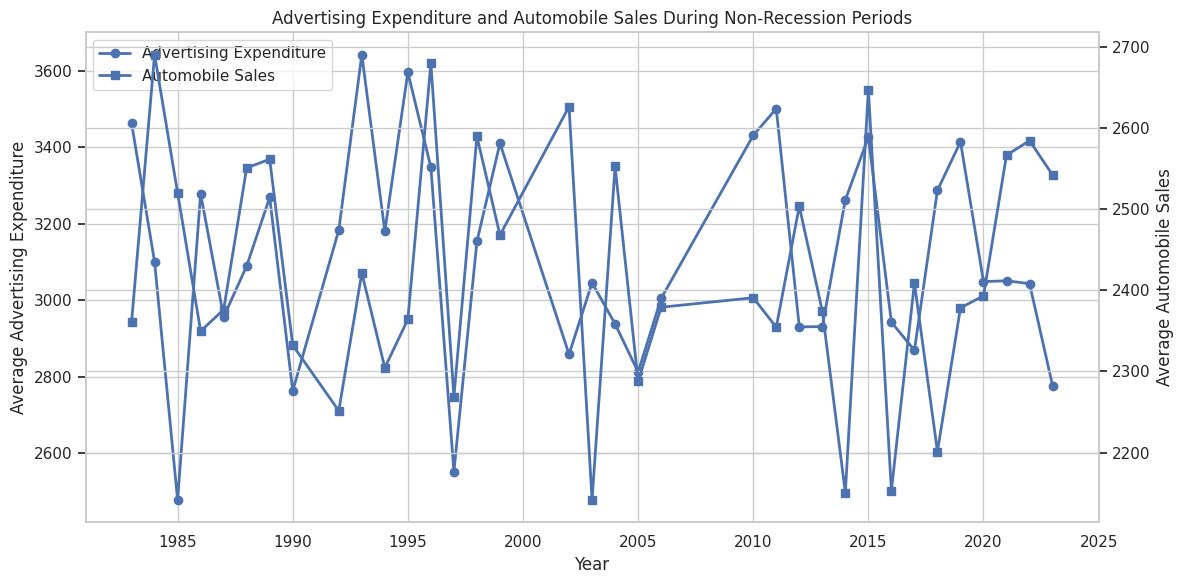

In [3]:
# TASK 1.2
non_recession = df[df["Recession"] == 0]

ad_sales = non_recession.groupby("Year", as_index=False)[
    ["Advertising_Expenditure", "Automobile_Sales"]
].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    ad_sales["Year"],
    ad_sales["Advertising_Expenditure"],
    marker="o",
    linewidth=2,
    label="Advertising Expenditure"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Average Advertising Expenditure")

ax2 = ax1.twinx()
ax2.plot(
    ad_sales["Year"],
    ad_sales["Automobile_Sales"],
    marker="s",
    linewidth=2,
    label="Automobile Sales"
)
ax2.set_ylabel("Average Automobile Sales")

ax1.set_title(
    "Advertising Expenditure and Automobile Sales During Non-Recession Periods"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.tight_layout()
plt.show()


## Task 1.3 — Grouped bar chart comparing vehicle-wise sales during recession and non-recession

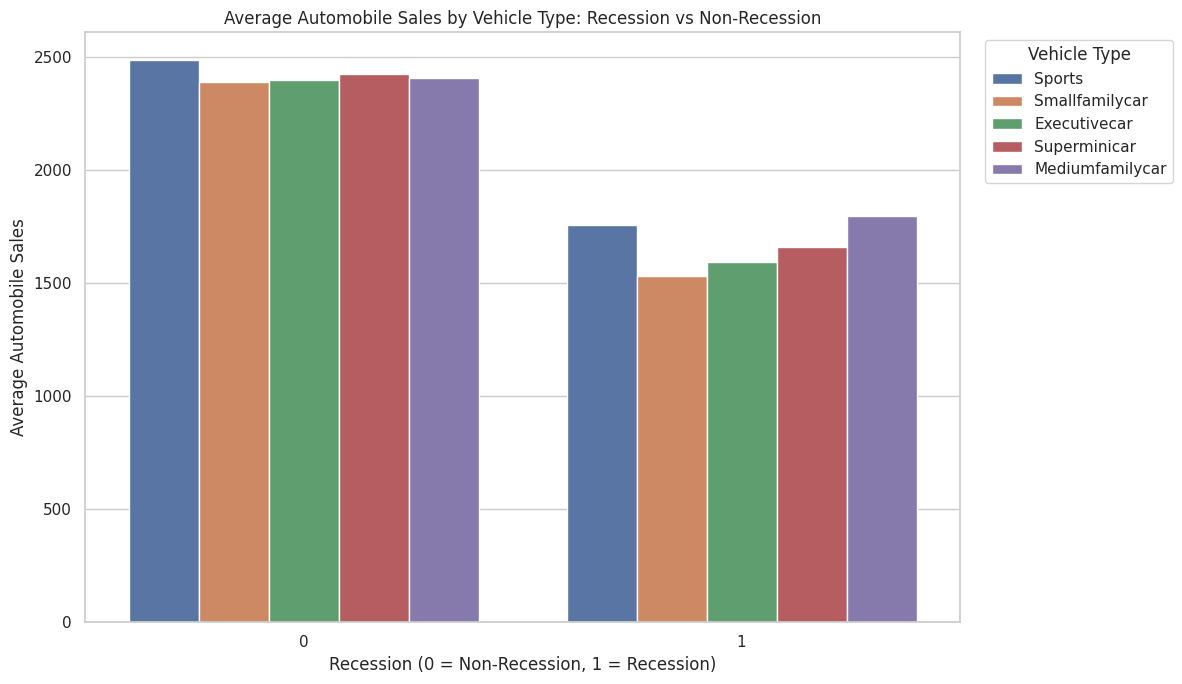

In [4]:
# TASK 1.3
plt.figure(figsize=(12, 7))

sns.barplot(
    data=df,
    x="Recession",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    estimator="mean",
    errorbar=None
)

plt.xlabel("Recession (0 = Non-Recession, 1 = Recession)")
plt.ylabel("Average Automobile Sales")
plt.title(
    "Average Automobile Sales by Vehicle Type: "
    "Recession vs Non-Recession"
)
plt.legend(
    title="Vehicle Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


## Task 1.4 — Subplots comparing GDP during recession and non-recession periods

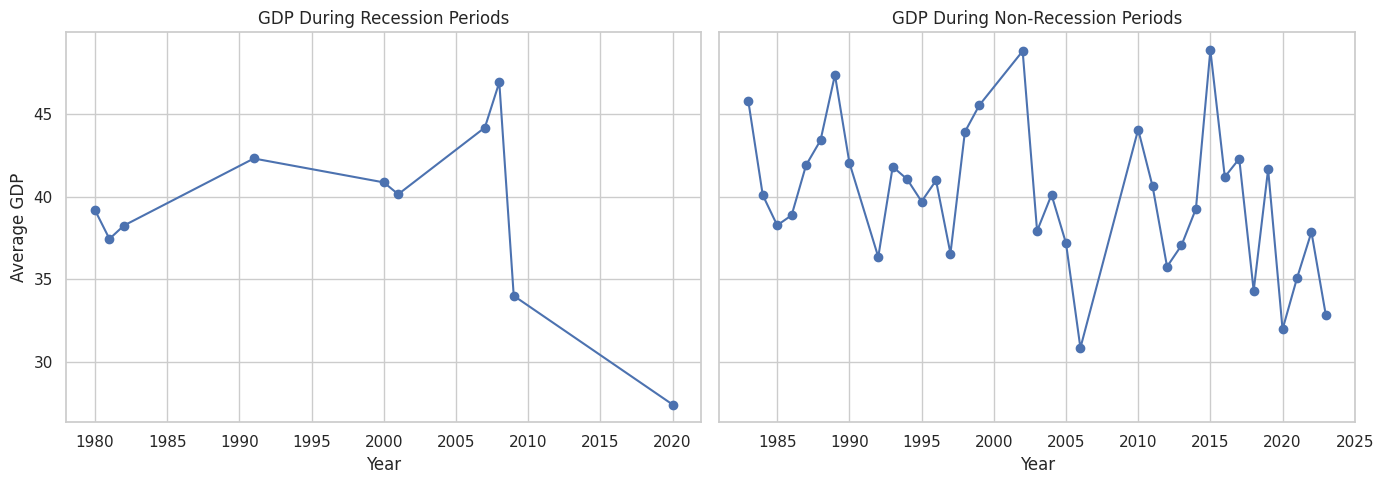

In [5]:
# TASK 1.4
recession_gdp = (
    df[df["Recession"] == 1]
    .groupby("Year")["GDP"]
    .mean()
)

non_recession_gdp = (
    df[df["Recession"] == 0]
    .groupby("Year")["GDP"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(
    recession_gdp.index,
    recession_gdp.values,
    marker="o"
)
axes[0].set_title("GDP During Recession Periods")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average GDP")

axes[1].plot(
    non_recession_gdp.index,
    non_recession_gdp.values,
    marker="o"
)
axes[1].set_title("GDP During Non-Recession Periods")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()


## Task 1.5 — Bubble plot displaying the impact of seasonality on Automobile Sales

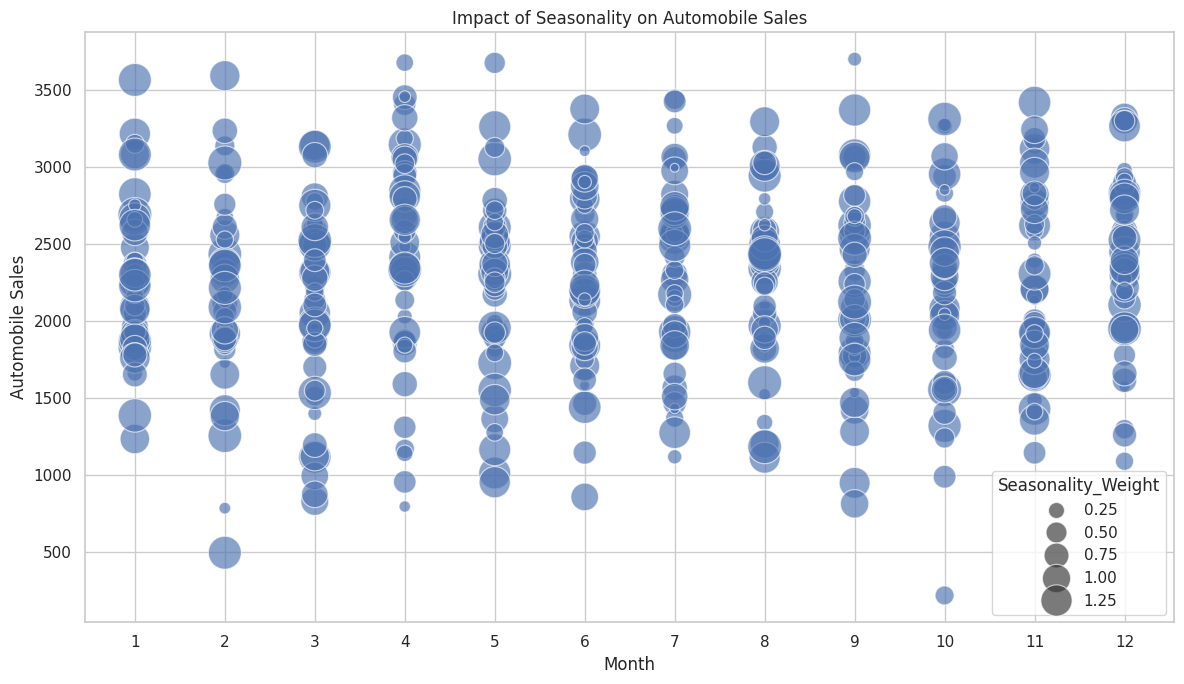

In [6]:
# TASK 1.5
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Month",
    y="Automobile_Sales",
    size="Seasonality_Weight",
    sizes=(40, 600),
    alpha=0.65,
    legend=True
)

plt.xlabel("Month")
plt.ylabel("Automobile Sales")
plt.title("Impact of Seasonality on Automobile Sales")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()


## Task 1.6 — Scatter plot identifying the relationship between vehicle price and sales during recession

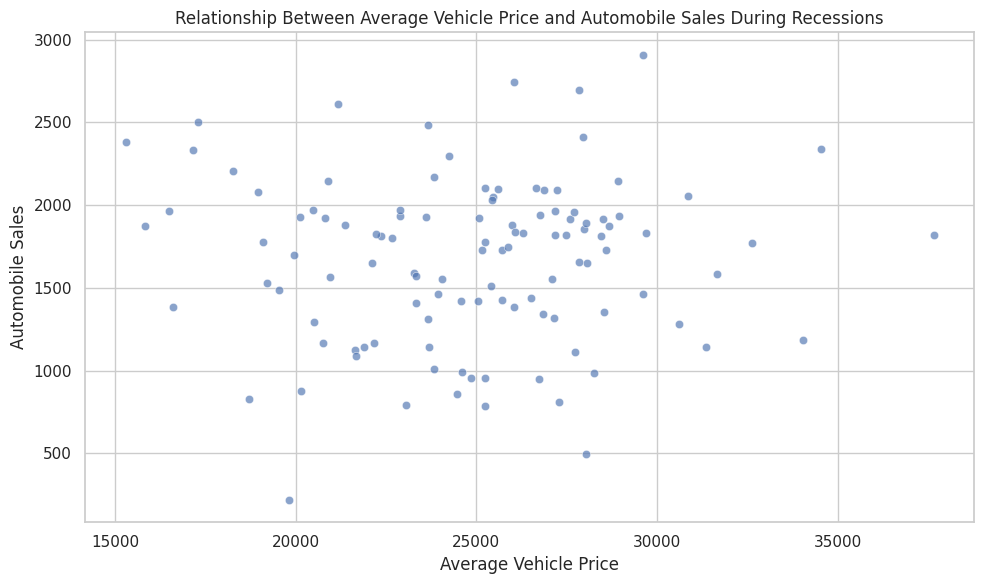

In [7]:
# TASK 1.6
recession_data = df[df["Recession"] == 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=recession_data,
    x="Price",
    y="Automobile_Sales",
    alpha=0.65
)

plt.xlabel("Average Vehicle Price")
plt.ylabel("Automobile Sales")
plt.title(
    "Relationship Between Average Vehicle Price and "
    "Automobile Sales During Recessions"
)
plt.tight_layout()
plt.show()


## Task 1.7 — Pie chart showing advertising expenditure during recession and non-recession

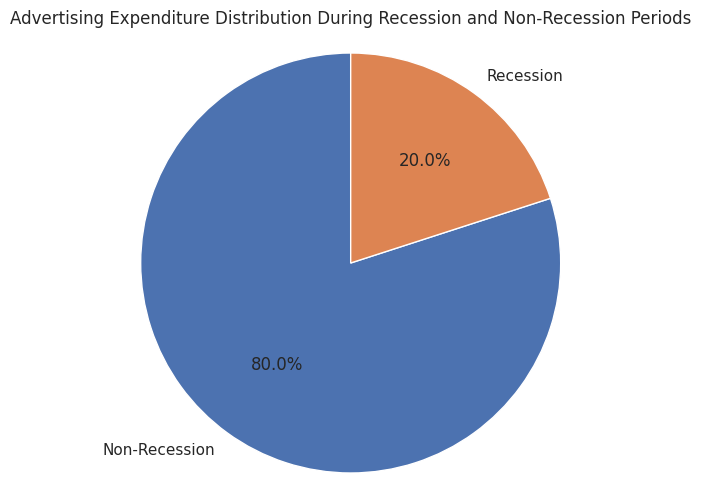

In [8]:
# TASK 1.7
advertising_by_period = (
    df.groupby("Recession")["Advertising_Expenditure"]
    .sum()
)

labels = ["Non-Recession", "Recession"]
sizes = [
    advertising_by_period.get(0, 0),
    advertising_by_period.get(1, 0)
]

plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90
)
plt.title(
    "Advertising Expenditure Distribution During "
    "Recession and Non-Recession Periods"
)
plt.axis("equal")
plt.show()


## Task 1.8 — Pie chart showing total advertising expenditure for each vehicle type during recession

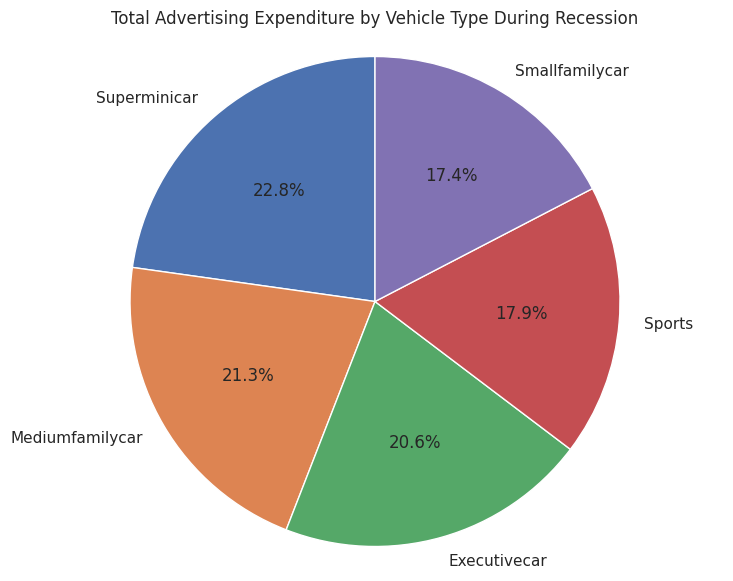

In [9]:
# TASK 1.8
recession_advertising = (
    df[df["Recession"] == 1]
    .groupby("Vehicle_Type")["Advertising_Expenditure"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 7))
plt.pie(
    recession_advertising.values,
    labels=recession_advertising.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title(
    "Total Advertising Expenditure by Vehicle Type "
    "During Recession"
)
plt.axis("equal")
plt.show()


## Task 1.9 — Line chart analyzing the effect of unemployment rate on vehicle type and sales during recession

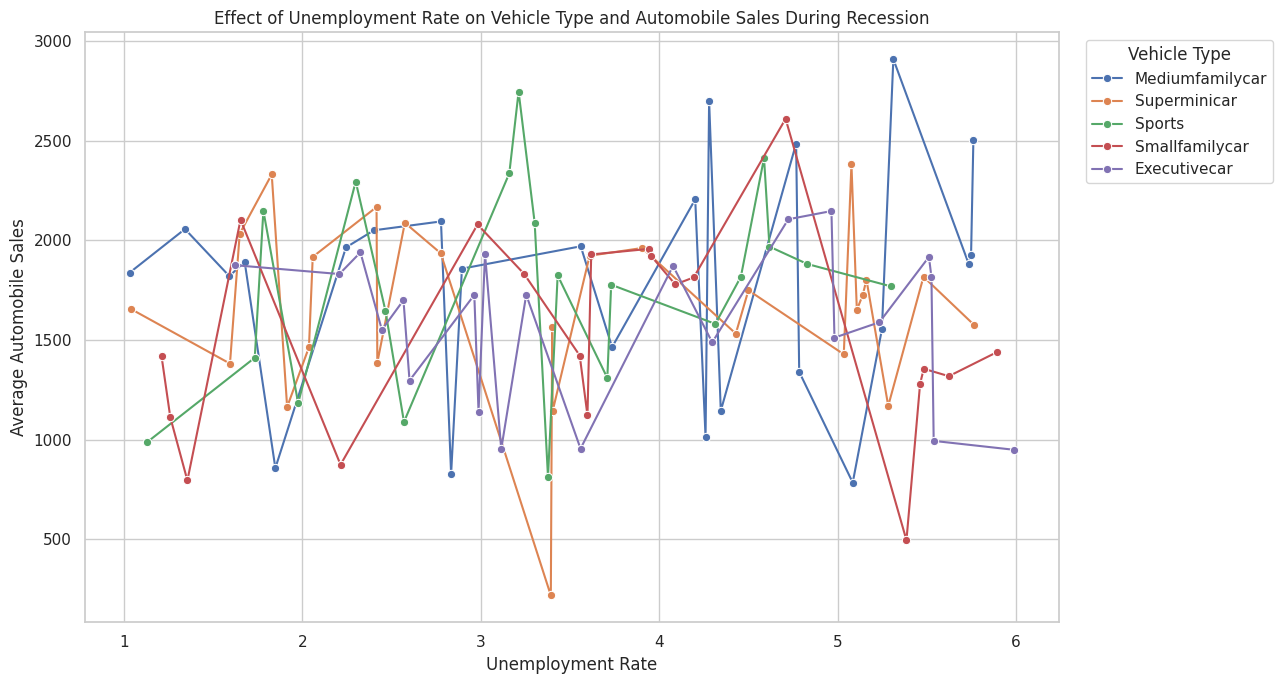

In [10]:
# TASK 1.9
recession_unemployment = (
    df[df["Recession"] == 1]
    .groupby(["Unemployment_Rate", "Vehicle_Type"], as_index=False)
    ["Automobile_Sales"]
    .mean()
    .sort_values("Unemployment_Rate")
)

plt.figure(figsize=(13, 7))

sns.lineplot(
    data=recession_unemployment,
    x="Unemployment_Rate",
    y="Automobile_Sales",
    hue="Vehicle_Type",
    marker="o"
)

plt.xlabel("Unemployment Rate")
plt.ylabel("Average Automobile Sales")
plt.title(
    "Effect of Unemployment Rate on Vehicle Type "
    "and Automobile Sales During Recession"
)
plt.legend(
    title="Vehicle Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()


## Final verification

The notebook contains all nine required visualization tasks:

1. Average annual automobile sales.
2. Advertising expenditure and automobile sales during non-recession periods.
3. Vehicle-wise grouped bar chart for recession vs non-recession.
4. GDP comparison using recession/non-recession subplots.
5. Seasonality bubble plot.
6. Price vs sales scatter plot during recession.
7. Advertising expenditure distribution by recession status.
8. Advertising expenditure by vehicle type during recession.
9. Unemployment rate vs automobile sales by vehicle type during recession.


In [11]:
# Final verification cell
required_columns = [
    "Year", "Month", "Recession", "Automobile_Sales",
    "GDP", "Seasonality_Weight", "Price",
    "Advertising_Expenditure", "Vehicle_Type",
    "Unemployment_Rate"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Required columns missing:", missing_columns)
print("All required visualization tasks are present: 1.1 through 1.9.")
print("Notebook execution completed successfully.")


Required columns missing: []
All required visualization tasks are present: 1.1 through 1.9.
Notebook execution completed successfully.
